<a href="https://colab.research.google.com/github/AttackHeli32/fars-florida-crash-analysis/blob/main/FARS_Florida_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import urllib.request

url = "https://raw.githubusercontent.com/AttackHeli32/fars-florida-crash-analysis/main/data/fars_data.zip"

urllib.request.urlretrieve(url, "fars_data.zip")

with zipfile.ZipFile("fars_data.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import pandas as pd

person = pd.read_csv("/content/person.csv")
vehicle = pd.read_csv("/content/vehicle.csv")
accident = pd.read_csv("/content/accident.csv")

print(person.columns)
print(vehicle.columns)
print(accident.columns)

/tmp/ipykernel_15708/2140519908.py:4: DtypeWarning: Columns (53,63,67) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle = pd.read_csv("/content/vehicle.csv")


Index(['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'PER_NO', 'VE_FORMS',
       'COUNTY', 'MONTH', 'MONTHNAME', 'DAY',
       ...
       'DEVTYPE', 'DEVTYPENAME', 'DEVMOTOR', 'DEVMOTORNAME', 'LOCATION',
       'LOCATIONNAME', 'WORK_INJ', 'WORK_INJNAME', 'HISPANIC', 'HISPANICNAME'],
      dtype='object', length=126)
Index(['STATE', 'STATENAME', 'ST_CASE', 'VEH_NO', 'VE_FORMS', 'MONTH',
       'MONTHNAME', 'DAY', 'DAYNAME', 'HOUR',
       ...
       'PCRASH4', 'PCRASH4NAME', 'PCRASH5', 'PCRASH5NAME', 'ACC_TYPE',
       'ACC_TYPENAME', 'ACC_CONFIG', 'ACC_CONFIGNAME', 'MODEL', 'DEATHS'],
      dtype='object', length=203)
Index(['STATE', 'STATENAME', 'ST_CASE', 'PEDS', 'PERNOTMVIT', 'VE_TOTAL',
       'VE_FORMS', 'PVH_INVL', 'PERSONS', 'PERMVIT', 'COUNTY', 'COUNTYNAME',
       'CITY', 'CITYNAME', 'MONTH', 'MONTHNAME', 'DAY', 'DAYNAME', 'DAY_WEEK',
       'DAY_WEEKNAME', 'YEAR', 'HOUR', 'HOURNAME', 'MINUTE', 'MINUTENAME',
       'TWAY_ID', 'TWAY_ID2', 'ROUTE', 'ROUTENAME', 'RUR_URB', 'RUR_URB

In [ ]:
import pandas as pd

# reload with low_memory fix
person = pd.read_csv("/content/person.csv", low_memory=False)
vehicle = pd.read_csv("/content/vehicle.csv", low_memory=False)
accident = pd.read_csv("/content/accident.csv", low_memory=False)

# ----------------------------------
# 1. KEEP DRIVERS ONLY
# ----------------------------------

drivers = person[person["PER_TYP"] == 1].copy()

print("Drivers count:", len(drivers))

# ----------------------------------
# 2. MERGE VEHICLE DATA
# ----------------------------------

drivers = drivers.merge(
    vehicle[["ST_CASE","VEH_NO","SPEEDREL"]],
    on=["ST_CASE","VEH_NO"],
    how="left"
)

# ----------------------------------
# 3. MERGE CRASH DATA
# ----------------------------------

drivers = drivers.merge(
    accident[["ST_CASE","COUNTY","HOUR"]],
    on="ST_CASE",
    how="left"
)

print("Merged dataset rows:", len(drivers))

drivers.head()

Drivers count: 57939
Merged dataset rows: 57939


,STATE,STATENAME,ST_CASE,VEH_NO,PER_NO,VE_FORMS,COUNTY_x,MONTH,MONTHNAME,DAY,...,DEVMOTORNAME,LOCATION,LOCATIONNAME,WORK_INJ,WORK_INJNAME,HISPANIC,HISPANICNAME,SPEEDREL,COUNTY_y,HOUR_y
0,1,Alabama,10001,1,1,1,13,1,January,4,...,NaN,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic,0,13,22
1,1,Alabama,10002,1,1,1,97,3,March,20,...,NaN,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic,0,97,2
2,1,Alabama,10003,1,1,1,89,3,March,18,...,NaN,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic,3,89,22
3,1,Alabama,10004,1,1,1,53,3,March,17,...,NaN,0,Occupant of a Motor Vehicle,8,Not Applicable (not a fatality),0,Not A Fatality (not Applicable),3,53,19
4,1,Alabama,10005,1,1,1,3,3,March,17,...,NaN,0,Occupant of a Motor Vehicle,0,No,7,Non-Hispanic,4,3,14


In [ ]:
drivers = drivers[drivers["STATE"] == 12].copy()

print("Florida drivers only:", len(drivers))
drivers[["STATE", "STATENAME"]].drop_duplicates()

Florida drivers only: 5027


,STATE,STATENAME
11496,12,Florida


In [ ]:
[col for col in drivers.columns if "LIC" in col.upper() or "STATE" in col.upper() or "RES" in col.upper()]

['STATE',
 'STATENAME',
 'REST_USE',
 'REST_USENAME',
 'REST_MIS',
 'REST_MISNAME',
 'ALC_RES',
 'ALC_RESNAME']

In [ ]:
[c for c in person.columns if "LIC" in c.upper()]

[]

In [ ]:
[c for c in person.columns if "STATE" in c.upper()]

['STATE', 'STATENAME']

In [ ]:
[c for c in person.columns if "HOME" in c.upper() or "RESID" in c.upper()]

[]

In [ ]:
drivers = drivers.rename(columns={
    "COUNTY_y": "COUNTY",
    "HOUR_y": "HOUR"
})

In [ ]:
drivers[["COUNTY","HOUR"]].head()

,COUNTY,HOUR
11496,81,3
11497,81,3
11498,81,9
11499,51,12
11500,51,12


In [ ]:
import pandas as pd

# Reload raw files
person = pd.read_csv("/content/person.csv", low_memory=False)
vehicle = pd.read_csv("/content/vehicle.csv", low_memory=False)
accident = pd.read_csv("/content/accident.csv", low_memory=False)

# 1. Keep drivers only
drivers = person[person["PER_TYP"] == 1].copy()

print("Driver rows before merge:", len(drivers))

# 2. Merge in vehicle variables INCLUDING L_STATE
drivers = drivers.merge(
    vehicle[["ST_CASE", "VEH_NO", "SPEEDREL", "L_STATE", "L_STATENAME", "REG_STAT", "REG_STATNAME"]],
    on=["ST_CASE", "VEH_NO"],
    how="left"
)

# 3. Merge in accident variables
drivers = drivers.merge(
    accident[["ST_CASE", "COUNTY", "COUNTYNAME", "HOUR", "YEAR", "MONTH", "WEATHER", "WEATHERNAME", "LGT_COND", "LGT_CONDNAME"]],
    on="ST_CASE",
    how="left"
)

# 4. Keep Florida crashes only
drivers = drivers[drivers["STATE"] == 12].copy()

print("Florida driver rows:", len(drivers))

# 5. Check whether L_STATE is now present
print("L_STATE in drivers?", "L_STATE" in drivers.columns)
print(drivers[["L_STATE", "L_STATENAME"]].head())

Driver rows before merge: 57939
Florida driver rows: 5027
L_STATE in drivers? True
       L_STATE L_STATENAME
11496       12     Florida
11497       12     Florida
11498       12     Florida
11499       12     Florida
11500       12     Florida


In [ ]:
drivers["resident_group"] = drivers["L_STATE"].apply(
    lambda x: "Florida" if x == 12 else "Out-of-State"
)

print(drivers["resident_group"].value_counts(dropna=False))

resident_group
Florida         4476
Out-of-State     551
Name: count, dtype: int64


In [ ]:
"L_STATE" in drivers.columns

True

In [ ]:
drivers.columns.tolist()

['STATE',
 'STATENAME',
 'ST_CASE',
 'VEH_NO',
 'PER_NO',
 'VE_FORMS',
 'COUNTY_x',
 'MONTH_x',
 'MONTHNAME',
 'DAY',
 'DAYNAME',
 'HOUR_x',
 'HOURNAME',
 'MINUTE',
 'MINUTENAME',
 'HARM_EV',
 'HARM_EVNAME',
 'MAN_COLL',
 'MAN_COLLNAME',
 'SCH_BUS',
 'SCH_BUSNAME',
 'RUR_URB',
 'RUR_URBNAME',
 'FUNC_SYS',
 'FUNC_SYSNAME',
 'MOD_YEAR',
 'MOD_YEARNAME',
 'VPICMAKE',
 'VPICMAKENAME',
 'VPICMODEL',
 'VPICMODELNAME',
 'VPICBODYCLASS',
 'VPICBODYCLASSNAME',
 'MAKE',
 'MAKENAME',
 'BODY_TYP',
 'BODY_TYPNAME',
 'ICFINALBODY',
 'ICFINALBODYNAME',
 'GVWR_FROM',
 'GVWR_FROMNAME',
 'GVWR_TO',
 'GVWR_TONAME',
 'TOW_VEH',
 'TOW_VEHNAME',
 'SPEC_USE',
 'SPEC_USENAME',
 'EMER_USE',
 'EMER_USENAME',
 'ROLLOVER',
 'ROLLOVERNAME',
 'IMPACT1',
 'IMPACT1NAME',
 'FIRE_EXP',
 'FIRE_EXPNAME',
 'MAK_MOD',
 'MAK_MODNAME',
 'AGE',
 'AGENAME',
 'SEX',
 'SEXNAME',
 'PER_TYP',
 'PER_TYPNAME',
 'INJ_SEV',
 'INJ_SEVNAME',
 'SEAT_POS',
 'SEAT_POSNAME',
 'REST_USE',
 'REST_USENAME',
 'REST_MIS',
 'REST_MISNAME',
 'HELM

In [ ]:
drivers = drivers.merge(
    vehicle[["ST_CASE","VEH_NO","ACC_TYPE","ACC_TYPENAME"]],
    on=["ST_CASE","VEH_NO"],
    how="left"
)

In [ ]:
print("ACC_TYPENAME" in drivers.columns)

True


In [ ]:
drivers["ACC_TYPENAME"].value_counts().head(10)

,count
ACC_TYPENAME,
C13-Single Driver-Forward Impact-Pedestrian/ Animal,971
M98-Other Crash Type,720
A1-Single Driver-Right Roadside Departure-Drive Off Road,378
"J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)",367
"J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)",367
B6-Single Driver-Left Roadside Departure-Drive Off Road,275
"G51-Same Trafficway, Opposite Direction-Head-On-Lateral Move (Going Straight)",143
"G50-Same Trafficway, Opposite Direction-Head-On-Lateral Move (Left/Right)",143
"D24-Same Trafficway, Same Direction-Rear End-Slower",142


In [ ]:
top_types = drivers["ACC_TYPENAME"].value_counts().head(5).index
print(top_types)

Index(['C13-Single Driver-Forward Impact-Pedestrian/ Animal',
       'M98-Other Crash Type',
       'A1-Single Driver-Right Roadside Departure-Drive Off Road',
       'J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)',
       'J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)'],
      dtype='object', name='ACC_TYPENAME')


In [ ]:
subset = drivers[drivers["ACC_TYPENAME"].isin(top_types)]

In [ ]:
import pandas as pd

table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])
print(table)

ACC_TYPENAME    A1-Single Driver-Right Roadside Departure-Drive Off Road  \
resident_group                                                             
Florida                                                       344          
Out-of-State                                                   34          

ACC_TYPENAME    C13-Single Driver-Forward Impact-Pedestrian/ Animal  \
resident_group                                                        
Florida                                                       800     
Out-of-State                                                  171     

ACC_TYPENAME    J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)  \
resident_group                                                                                                       
Florida                                                       342                                                    
Out-of-State                                            

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)
print("degrees of freedom:", dof)

Chi-square: 58.94316145172469
p-value: 4.836710591515439e-12
degrees of freedom: 4


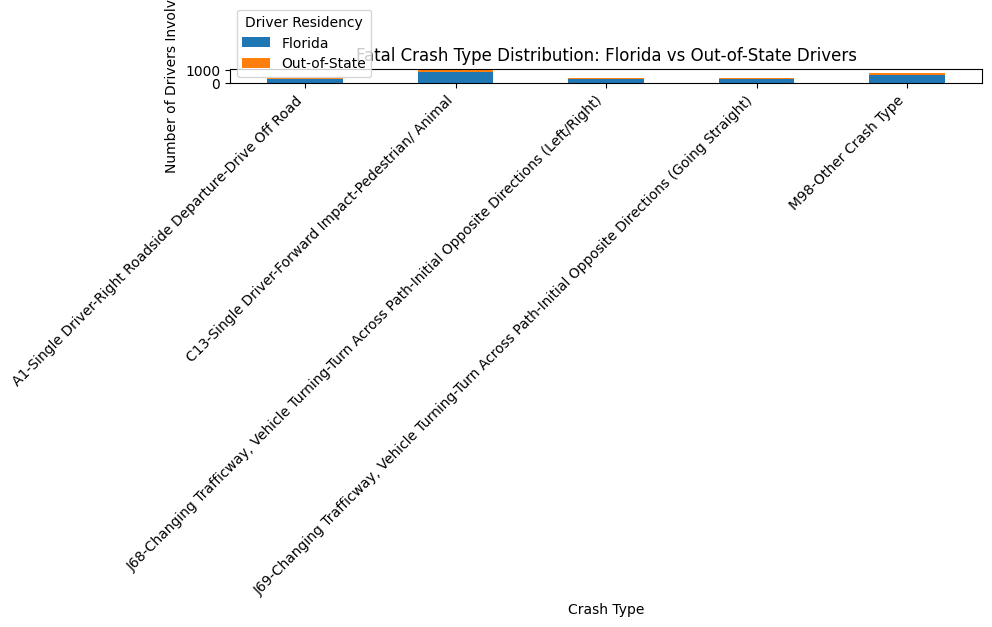

In [ ]:
import matplotlib.pyplot as plt

# contingency table you created earlier
table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])

# plot
table.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Fatal Crash Type Distribution: Florida vs Out-of-State Drivers")
plt.xlabel("Crash Type")
plt.ylabel("Number of Drivers Involved")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Driver Residency")
plt.tight_layout()

plt.show()

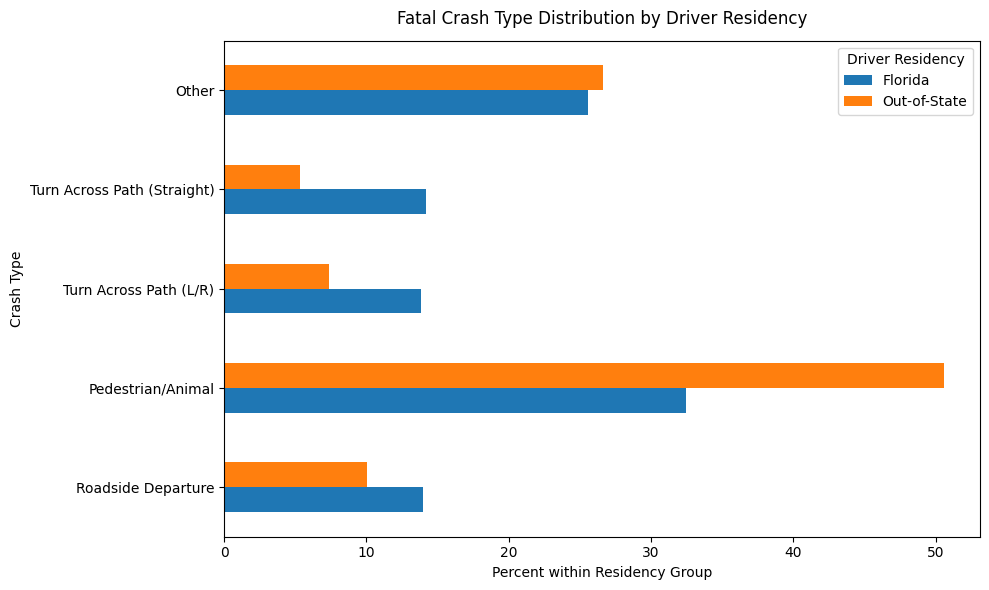

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild table if needed
table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])

# Shorten long crash type labels
label_map = {
    "A1-Single Driver-Right Roadside Departure-Drive Off Road": "Roadside Departure",
    "C13-Single Driver-Forward Impact-Pedestrian/ Animal": "Pedestrian/Animal",
    "J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)": "Turn Across Path (L/R)",
    "J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)": "Turn Across Path (Straight)",
    "M98-Other Crash Type": "Other"
}

table = table.rename(columns=label_map)

# Convert to row percentages
prop_table = table.div(table.sum(axis=1), axis=0) * 100

# Transpose so crash types are on y-axis
plot_df = prop_table.T

# Create horizontal grouped bar chart
ax = plot_df.plot(kind="barh", figsize=(10, 6))

plt.title("Fatal Crash Type Distribution by Driver Residency", pad=12)
plt.xlabel("Percent within Residency Group")
plt.ylabel("Crash Type")
plt.legend(title="Driver Residency")
plt.tight_layout()
plt.show()

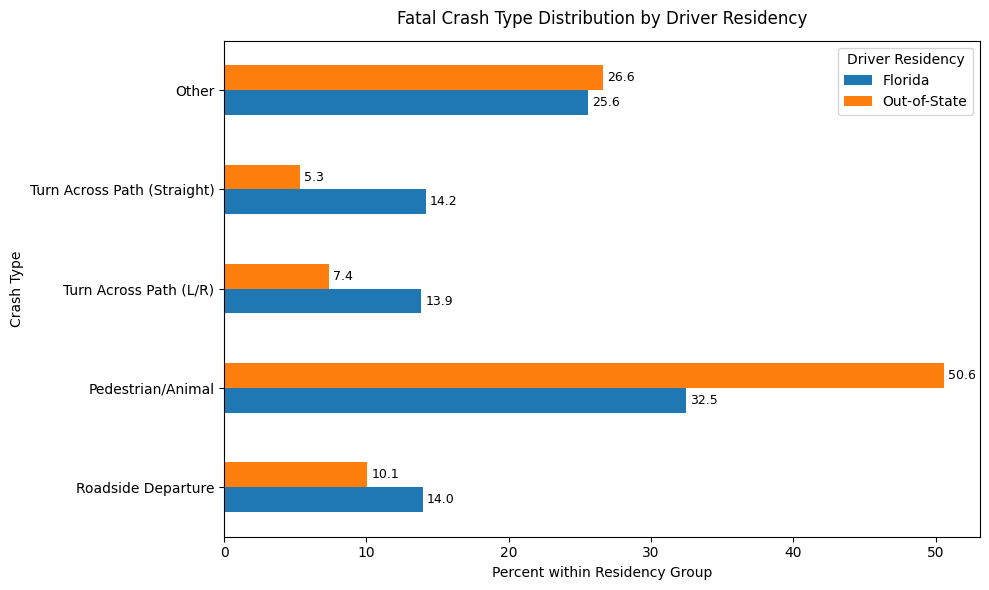

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])

label_map = {
    "A1-Single Driver-Right Roadside Departure-Drive Off Road": "Roadside Departure",
    "C13-Single Driver-Forward Impact-Pedestrian/ Animal": "Pedestrian/Animal",
    "J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)": "Turn Across Path (L/R)",
    "J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)": "Turn Across Path (Straight)",
    "M98-Other Crash Type": "Other"
}

table = table.rename(columns=label_map)
prop_table = table.div(table.sum(axis=1), axis=0) * 100
plot_df = prop_table.T

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind="barh", ax=ax)

ax.set_title("Fatal Crash Type Distribution by Driver Residency", pad=12)
ax.set_xlabel("Percent within Residency Group")
ax.set_ylabel("Crash Type")
ax.legend(title="Driver Residency")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

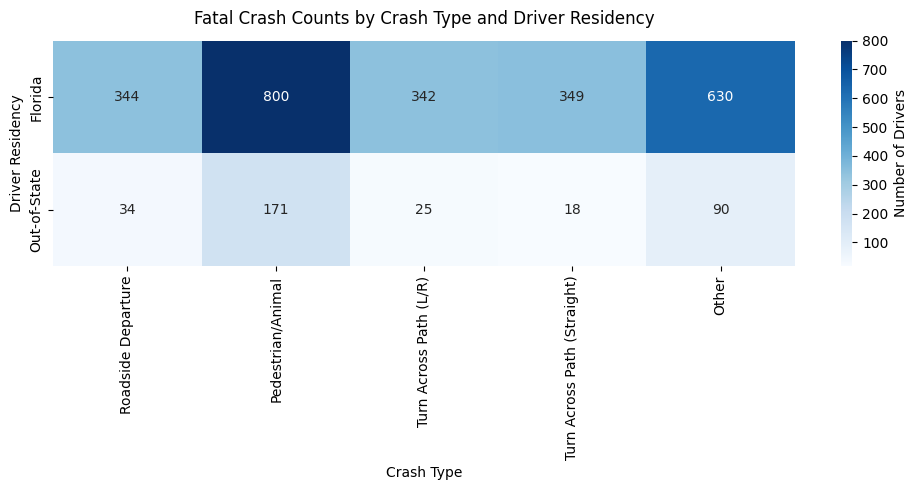

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Rebuild contingency table if needed
table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])

# Shorten labels again for readability
label_map = {
    "A1-Single Driver-Right Roadside Departure-Drive Off Road": "Roadside Departure",
    "C13-Single Driver-Forward Impact-Pedestrian/ Animal": "Pedestrian/Animal",
    "J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)": "Turn Across Path (L/R)",
    "J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)": "Turn Across Path (Straight)",
    "M98-Other Crash Type": "Other"
}

table = table.rename(columns=label_map)

plt.figure(figsize=(10,5))

sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Number of Drivers"}
)

plt.title("Fatal Crash Counts by Crash Type and Driver Residency", pad=12)
plt.xlabel("Crash Type")
plt.ylabel("Driver Residency")

plt.tight_layout()
plt.show()

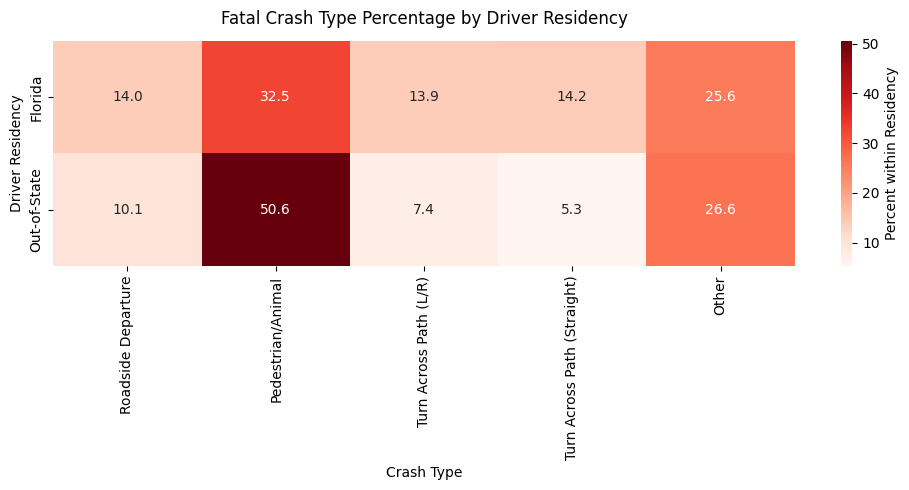

In [ ]:
prop_table = table.div(table.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,5))

sns.heatmap(
    prop_table,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Percent within Residency"}
)

plt.title("Fatal Crash Type Percentage by Driver Residency", pad=12)
plt.xlabel("Crash Type")
plt.ylabel("Driver Residency")

plt.tight_layout()
plt.savefig("fatal_crash_type_residency_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

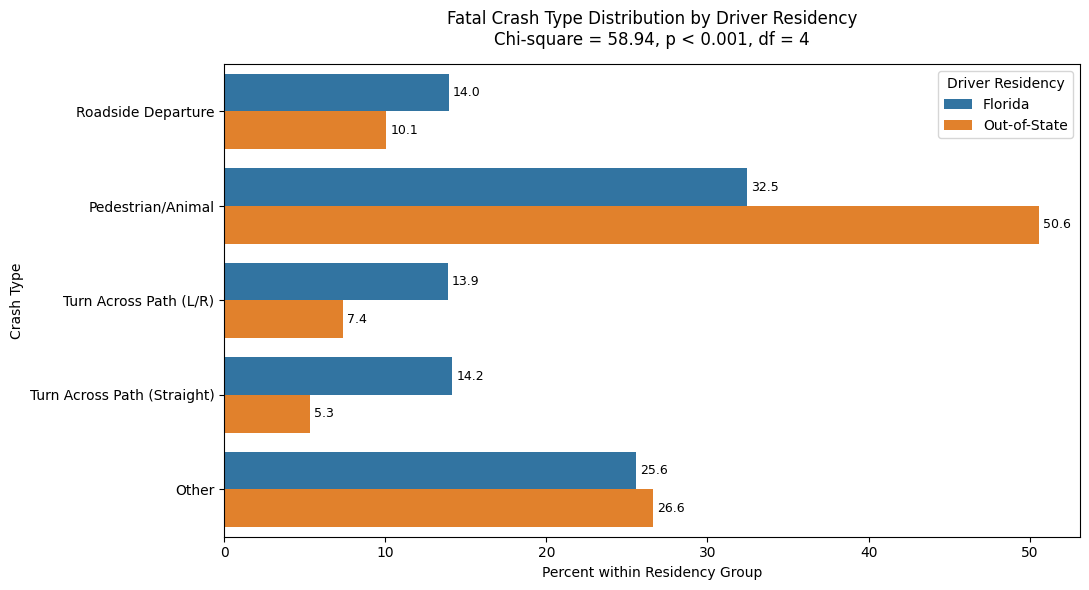

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build contingency table
table = pd.crosstab(subset["resident_group"], subset["ACC_TYPENAME"])

# Short labels
label_map = {
    "A1-Single Driver-Right Roadside Departure-Drive Off Road": "Roadside Departure",
    "C13-Single Driver-Forward Impact-Pedestrian/ Animal": "Pedestrian/Animal",
    "J68-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Left/Right)": "Turn Across Path (L/R)",
    "J69-Changing Trafficway, Vehicle Turning-Turn Across Path-Initial Opposite Directions (Going Straight)": "Turn Across Path (Straight)",
    "M98-Other Crash Type": "Other"
}

table = table.rename(columns=label_map)

# Convert to percentages within each residency group
prop_table = table.div(table.sum(axis=1), axis=0) * 100

# Put into long format for seaborn
plot_df = prop_table.reset_index().melt(
    id_vars="resident_group",
    var_name="Crash Type",
    value_name="Percent"
)

# Plot
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=plot_df,
    y="Crash Type",
    x="Percent",
    hue="resident_group"
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

# Title and labels
plt.title(
    "Fatal Crash Type Distribution by Driver Residency\n"
    "Chi-square = 58.94, p < 0.001, df = 4",
    pad=14
)
plt.xlabel("Percent within Residency Group")
plt.ylabel("Crash Type")
plt.legend(title="Driver Residency")
plt.tight_layout()
plt.savefig("fatal_crash_type_residency_publication_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
[c for c in drivers.columns if "HOUR" in c]

['HOUR_x', 'HOURNAME', 'HOUR_y']

In [ ]:
# clean up duplicate hour columns
drivers = drivers.rename(columns={"HOUR_y": "HOUR_CRASH"})

# create day/night variable
drivers["time_of_day"] = drivers["HOUR_CRASH"].apply(
    lambda x: "Night" if (x >= 18 or x < 6) else "Day"
)

print(drivers["time_of_day"].value_counts(dropna=False))

time_of_day
Night    2808
Day      2219
Name: count, dtype: int64


In [ ]:
night_table = pd.crosstab(drivers["resident_group"], drivers["time_of_day"])
print(night_table)

time_of_day      Day  Night
resident_group             
Florida         2045   2431
Out-of-State     174    377


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

night_counts = night_table["Night"]
total_counts = night_table.sum(axis=1)

z_stat, p_value = proportions_ztest(night_counts, total_counts)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: -6.293604571878766
p-value: 3.101773792171998e-10


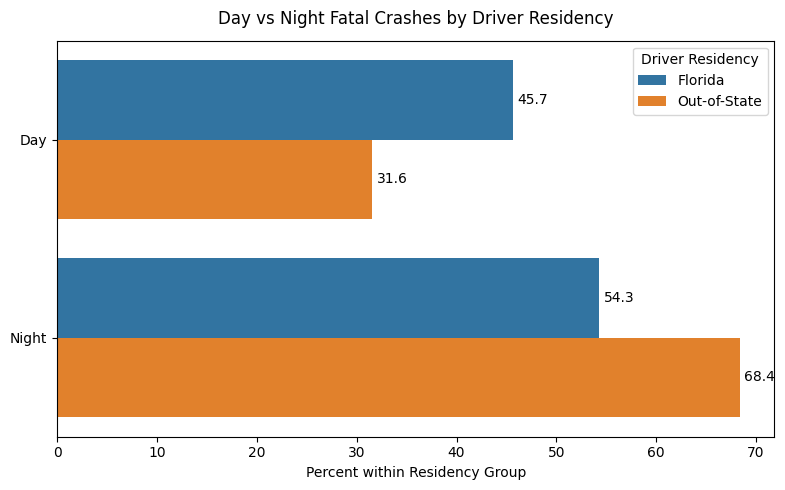

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

night_prop = night_table.div(night_table.sum(axis=1), axis=0) * 100

plot_df = night_prop.reset_index().melt(
    id_vars="resident_group",
    var_name="Crash Time",
    value_name="Percent"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="Percent",
    y="Crash Time",
    hue="resident_group"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Day vs Night Fatal Crashes by Driver Residency", pad=12)
plt.xlabel("Percent within Residency Group")
plt.ylabel("")
plt.legend(title="Driver Residency")

plt.tight_layout()
plt.savefig("day_vs_night_crashes.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
drivers = drivers.drop(columns=["HOUR_x"], errors="ignore")

In [ ]:
drivers["speeding"] = drivers["SPEEDREL"].apply(
    lambda x: "Speeding" if x > 0 else "No Speeding"
)

drivers["speeding"].value_counts()

,count
speeding,
No Speeding,4712
Speeding,315


In [ ]:
speed_table = pd.crosstab(drivers["resident_group"], drivers["speeding"])
print(speed_table)

speeding        No Speeding  Speeding
resident_group                       
Florida                4178       298
Out-of-State            534        17


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

speed_counts = speed_table["Speeding"]
total_counts = speed_table.sum(axis=1)

z_stat, p_value = proportions_ztest(speed_counts, total_counts)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: 3.264984856243743
p-value: 0.0010946992910273719


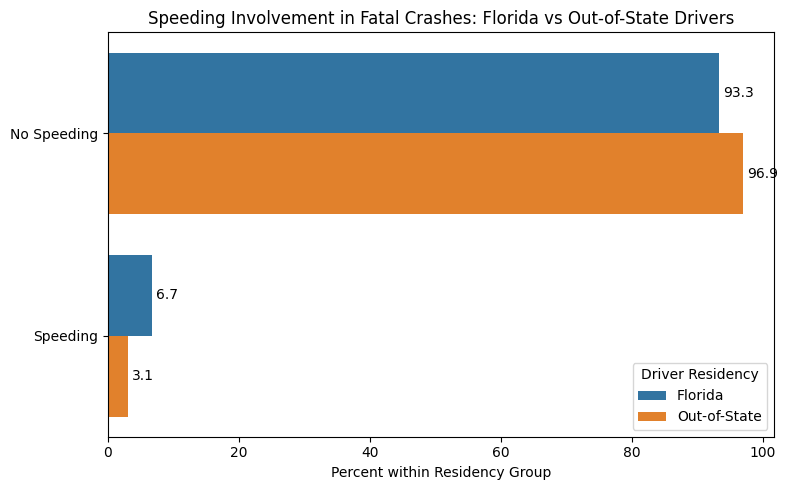

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

speed_prop = speed_table.div(speed_table.sum(axis=1), axis=0) * 100

plot_df = speed_prop.reset_index().melt(
    id_vars="resident_group",
    var_name="Speeding Involvement",
    value_name="Percent"
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=plot_df,
    x="Percent",
    y="Speeding Involvement",
    hue="resident_group"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Speeding Involvement in Fatal Crashes: Florida vs Out-of-State Drivers")
plt.xlabel("Percent within Residency Group")
plt.ylabel("")
plt.legend(title="Driver Residency")

plt.tight_layout()

plt.savefig("speeding_vs_residency.png", dpi=300, bbox_inches="tight")

plt.show()

['accident.csv', 'person.csv', 'vehicle.csv']
[12]
Driver_Type  Florida Driver  Out-of-State Driver
MONTH                                           
Jan                     271                 2506
Feb                     284                 2361
Mar                     306                 2470
Apr                     279                 2786
May                     278                 2951
Jun                     220                 2973
Jul                     238                 3163
Aug                     206                 3217
Sep                     254                 3155
Oct                     287                 3218
Nov                     266                 2822
Dec                     294                 2849


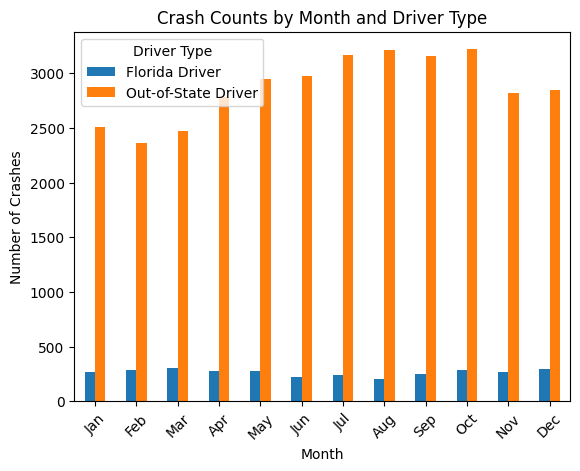

Chi-Square: 103.16989520077334
P-value: 4.1998818952347557e-17
Degrees of Freedom: 11


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io

url = "https://raw.githubusercontent.com/AttackHeli32/fars-florida-crash-analysis/main/data/fars_data.zip"

response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

df = pd.read_csv(zip_file.open(zip_file.namelist()[0]))

print(zip_file.namelist())

if 'STATE' in df.columns:
  df = df[df['STATE'] == 12]

print(df['STATE'].unique())

df = pd.read_csv(zip_file.open(zip_file.namelist()[0]))
df['Driver_Type'] = df['STATE'].apply(
    lambda x: 'Florida Driver' if x == 12 else 'Out-of-State Driver'
)
monthly_table = pd.crosstab(df['MONTH'], df['Driver_Type']).sort_index()

month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
monthly_table.index = monthly_table.index.map(month_names)

print(monthly_table)
monthly_table.plot(kind='bar')

plt.title('Crash Counts by Month and Driver Type')
plt.xlabel('Month')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45)

plt.legend(title='Driver Type')

plt.show()

import pandas as pd
from scipy.stats import chi2_contingency

data = [
    [271, 2506],
    [284, 2361],
    [306, 2470],
    [279, 2786],
    [278, 2951],
    [220, 2973],
    [238, 3163],
    [206, 3217],
    [254, 3155],
    [287, 3218],
    [266, 2822],
    [294, 2849],
]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df_test = pd.DataFrame(data, columns=['Florida Driver', 'Out-of-State Driver'], index = months)

chi2, p, dof, expected = chi2_contingency(df_test)

print("Chi-Square:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)


Preview with weather added:
  resident_group       WEATHERNAME
0        Florida  Fog, Smog, Smoke
1        Florida  Fog, Smog, Smoke
2        Florida             Clear
3        Florida            Cloudy
4        Florida            Cloudy

Weather Contingency Table:
weather_related  False  True 
resident_group               
Florida           4203    273
Out-of-State       495     56

--- Weather Proportion Test ---
Florida weather proportion: 0.06099195710455764
Out-of-State weather proportion: 0.10163339382940109
Z-statistic: -3.6399035690959662
P-value: 0.0002727401626862043
Conclusion: Reject H0 (Weather impact differs)


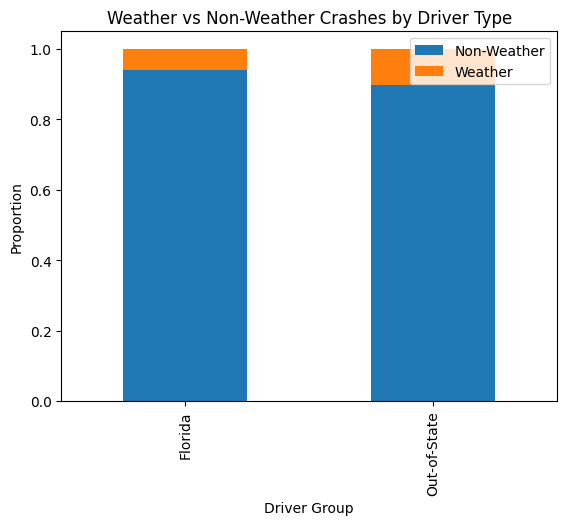

In [ ]:
import pandas as pd

#reload with low_memory  fix
person = pd.read_csv("/content/person.csv", low_memory=False)
vehicle = pd.read_csv("/content/vehicle.csv", low_memory=False)
accident = pd.read_csv("/content/accident.csv", low_memory=False)

# Filter Drivers Type
drivers = person[person["PER_TYP"] == 1]

# Filter Florida Accidents
drivers = drivers[drivers["STATE"] == 12]

# Merge Vehicle Data
drivers = drivers.merge(
    vehicle[["ST_CASE", "VEH_NO", "L_STATE", "SPEEDREL"]],
    on=["ST_CASE", "VEH_NO"],
    how="left"
)

# Define Driver Groups

drivers["resident_group"] = drivers["L_STATE"].apply(
    lambda x: "Florida" if x == 12 else "Out-of-State"
)

# Accident data merged from weather data

drivers = drivers.merge(
    accident[["ST_CASE", "WEATHER", "WEATHERNAME"]],
    on="ST_CASE",
    how="left"
)

print("\nPreview with weather added:")
print(drivers[["resident_group", "WEATHERNAME"]].head())

# Defined Adverse Weather

adverse_weather = [
    "Rain",
    "Snow",
    "Sleet or Hail",
    "Fog, Smog, Smoke",
    "Severe Crosswinds",
    "Blowing Sand, Soil, Dirt"
]

drivers["weather_related"] = drivers["WEATHERNAME"].isin(adverse_weather)

# Handle missing values
drivers["weather_related"] = drivers["weather_related"].fillna(False)

# Contingency Table
weather_table = pd.crosstab(
    drivers["resident_group"],
    drivers["weather_related"]
)

print("\nWeather Contingency Table:")
print(weather_table)

# Two-Proportion Z-Test

from statsmodels.stats.proportion import proportions_ztest

# Extract counts
fl_weather = weather_table.loc["Florida", True]
fl_total = weather_table.loc["Florida"].sum()

out_weather = weather_table.loc["Out-of-State", True]
out_total = weather_table.loc["Out-of-State"].sum()

# Run test
count = [fl_weather, out_weather]
nobs = [fl_total, out_total]

z_stat, p_value = proportions_ztest(count, nobs)

# Results
print("\n--- Weather Proportion Test ---")
print("Florida weather proportion:", fl_weather / fl_total)
print("Out-of-State weather proportion:", out_weather / out_total)
print("Z-statistic:", z_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject H0 (Weather impact differs)")
else:
    print("Conclusion: Fail to reject H0 (No significant difference)")

# Data Visualization
import matplotlib.pyplot as plt

(weather_table.div(weather_table.sum(axis=1), axis=0)
 .plot(kind="bar", stacked=True))

plt.title("Weather vs Non-Weather Crashes by Driver Type")
plt.ylabel("Proportion")
plt.xlabel("Driver Group")
plt.legend(["Non-Weather", "Weather"])
plt.show()

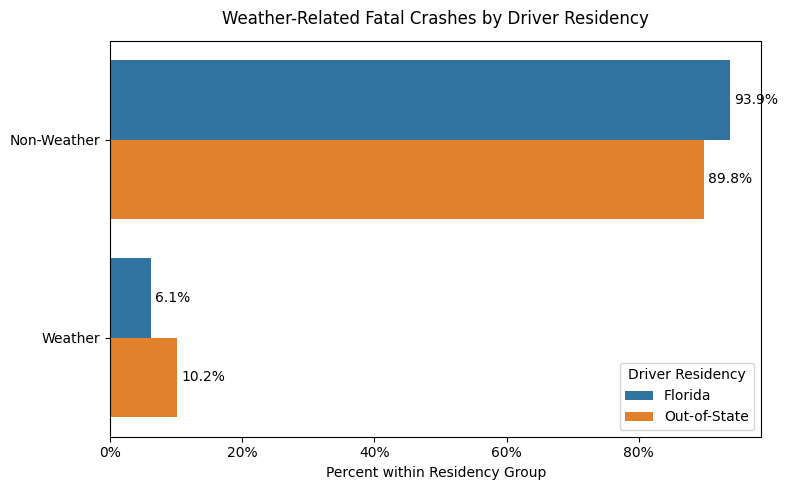

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

weather_prop = weather_table.div(weather_table.sum(axis=1), axis=0) * 100

plot_df = weather_prop.reset_index().melt(
    id_vars="resident_group",
    var_name="Weather Related",
    value_name="Percent"
)

plot_df["Weather Related"] = plot_df["Weather Related"].map({
    False: "Non-Weather",
    True: "Weather"
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=plot_df,
    x="Percent",
    y="Weather Related",
    hue="resident_group"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Weather-Related Fatal Crashes by Driver Residency", pad=12)
plt.xlabel("Percent within Residency Group")
plt.ylabel("")
plt.legend(title="Driver Residency")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [ ]:
# Merge county info from accident file
drivers = drivers.merge(
    accident[["ST_CASE", "COUNTYNAME"]],
    on="ST_CASE",
    how="left"
)

# Check it worked
print(drivers[["resident_group", "COUNTYNAME"]].head())

  resident_group    COUNTYNAME
0        Florida  MANATEE (81)
1        Florida  MANATEE (81)
2        Florida  MANATEE (81)
3        Florida   HENDRY (51)
4        Florida   HENDRY (51)



Full County Contingency Table (preview):
COUNTYNAME      ALACHUA (1)  BAKER (3)  BAY (5)  BRADFORD (7)  BREVARD (9)  \
resident_group                                                               
Florida                  72          9       39            11          151   
Out-of-State             10          2        1             2           14   

COUNTYNAME      BROWARD (11)  CALHOUN (13)  CHARLOTTE (15)  CITRUS (17)  \
resident_group                                                            
Florida                  286             7              46           32   
Out-of-State              38             2               4            3   

COUNTYNAME      CLAY (19)  ...  ST JOHNS (109)  ST LUCIE (111)  SUMTER (119)  \
resident_group             ...                                                 
Florida                61  ...              49              68            27   
Out-of-State            1  ...               8              10             4   

COUNTYNAME      SUWANNE

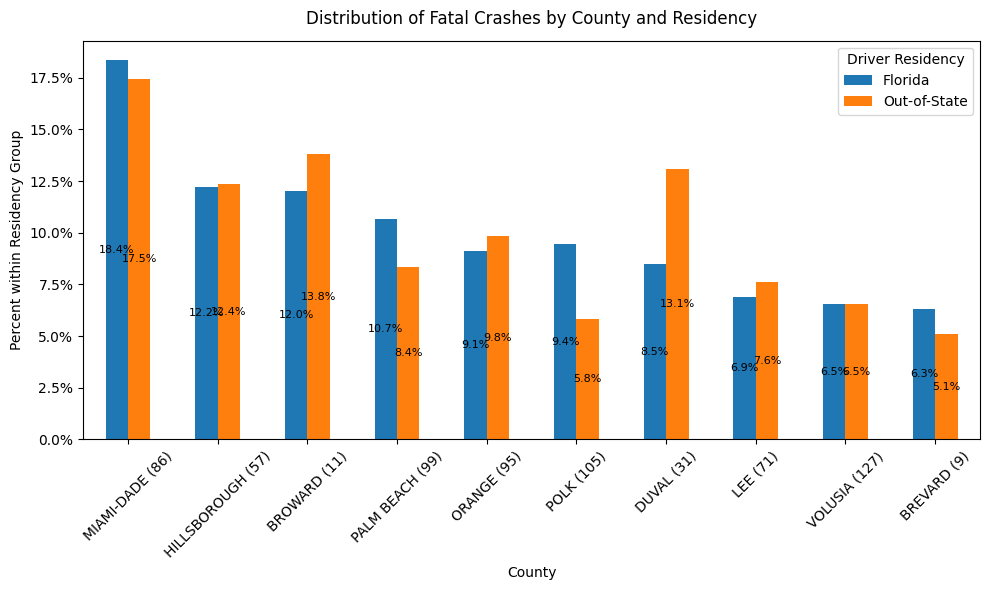

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency

# -------------------------------
# 1. CREATE CONTINGENCY TABLE
# -------------------------------

county_table = pd.crosstab(
    drivers["resident_group"],
    drivers["COUNTYNAME"]
)

print("\nFull County Contingency Table (preview):")
print(county_table.head())

# -------------------------------
# 2. REDUCE TO TOP COUNTIES
# (prevents sparse / noisy data)
# -------------------------------

top_counties = county_table.sum().sort_values(ascending=False).head(10).index
county_table_top = county_table[top_counties]

print("\nTop Counties Contingency Table:")
print(county_table_top)

# -------------------------------
# 3. CHI-SQUARE TEST
# -------------------------------

chi2, p, dof, expected = chi2_contingency(county_table_top)

print("\n--- Chi-Square Test: Residency vs County ---")
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# -------------------------------
# 4. INTERPRETATION
# -------------------------------

alpha = 0.05

if p < alpha:
    print("Conclusion: Reject H0 (Crash distribution differs by residency across counties)")
else:
    print("Conclusion: Fail to reject H0 (No significant difference)")

# -------------------------------
# 5. VISUALIZATION (PERCENT)
# -------------------------------

county_prop = county_table_top.div(county_table_top.sum(axis=1), axis=0) * 100

ax = county_prop.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribution of Fatal Crashes by County and Residency", pad=12)
plt.ylabel("Percent within Residency Group")
plt.xlabel("County")
plt.xticks(rotation=45)
plt.legend(title="Driver Residency")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add labels
for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.tight_layout()
plt.show()

**HYPOTHESIS 6 CODE PROVIDED BY DANIEL BRAUN**

In [ ]:
import pandas as pd
import os

YEARS = [2021, 2022, 2023]
OUTPUT_FILE = "florida_crashes_2021_2023.csv"

#columns from vehicle.csv to bring into the merged file
VEHICLE_COLS = ["ST_CASE", "VEH_NO", "L_STATE", "L_STATENAME"]

UNKNOWN_LICENSE_VALUES = {
    "Not Reported",
    "Reported as Unknown",
    "No Driver Present/Unknown if Driver Present",
}

def classify_resident(l_statename):
    if l_statename == "Florida":
        return "Yes"
    if pd.isna(l_statename) or l_statename in UNKNOWN_LICENSE_VALUES:
        return "Unknown"
    return "No"


def process_year(year):
    base = os.path.join(str(year))
    person_path  = os.path.join(base, "person.csv")
    vehicle_path = os.path.join(base, "vehicle.csv")

    if not os.path.exists(person_path):
        raise FileNotFoundError(f"Missing: {person_path}")
    if not os.path.exists(vehicle_path):
        raise FileNotFoundError(f"Missing: {vehicle_path}")
    person = pd.read_csv(person_path, low_memory=False)
    vehicle = pd.read_csv(vehicle_path, low_memory=False)

    #filter both to Florida
    fl_person  = person[person["STATENAME"] == "Florida"].copy()
    fl_vehicle = vehicle[vehicle["STATENAME"] == "Florida"][VEHICLE_COLS].copy()

    #merge license state info onto person rows
    merged = fl_person.merge(fl_vehicle, on=["ST_CASE", "VEH_NO"], how="left")

    #add year and residency columns
    merged["YEAR"] = year
    merged["FL_RESIDENT"] = merged["L_STATENAME"].apply(classify_resident)
    return merged

def main():
    all_years = []
    for year in YEARS:
        df = process_year(year)
        all_years.append(df)
    combined = pd.concat(all_years, ignore_index=True)
    combined.to_csv(OUTPUT_FILE, index=False)
if __name__ == "__main__":
    main()


/tmp/ipykernel_2537/4102709827.py:35: ParserWarning: Skipping line 1090: unexpected end of data

  vehicle = pd.read_csv(vehicle_path, engine='python', on_bad_lines='warn')


In [ ]:
import pandas as pd
from math import log, exp, sqrt
from scipy.stats import fisher_exact, chi2_contingency

def odds_ratio_ci(res_yes, res_no, non_yes, non_no):
    a = non_yes + 0.5
    b = non_no  + 0.5
    c = res_yes + 0.5
    d = res_no  + 0.5
    or_val = (a * d) / (b * c)
    se = sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low  = exp(log(or_val) - 1.96 * se)
    ci_high = exp(log(or_val) + 1.96 * se)
    return round(or_val, 3), round(ci_low, 3), round(ci_high, 3)

def run_fisher(res_yes, res_no, non_yes, non_no):
    _, p = fisher_exact([[res_yes, res_no], [non_yes, non_no]])
    or_val, ci_low, ci_high = odds_ratio_ci(res_yes, res_no, non_yes, non_no)
    return or_val, ci_low, ci_high, round(p, 4)

df = pd.read_csv("florida_crashes_2021_2023.csv", low_memory=False)

df = df[df['INJ_SEVNAME'] == 'Fatal Injury (K)']
df = df[df['FL_RESIDENT'].isin(['Yes', 'No'])]
df = df[df['PER_TYPNAME'] == 'Driver of a Motor Vehicle In-Transport']
df = df[df['AGE'] < 997].copy()

age_groups = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
bins = [0, 17, 24, 34, 44, 54, 64, 74, 120]
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=age_groups, right=True)

total_res = len(df[df['FL_RESIDENT'] == 'Yes'])
total_non = len(df[df['FL_RESIDENT'] == 'No'])

results = []

for grp in age_groups:
    sub = df[df['AGE_GROUP'] == grp]
    res = sub[sub['FL_RESIDENT'] == 'Yes']
    non = sub[sub['FL_RESIDENT'] == 'No']

    #age crashes uses chi Square
    res_in = len(res)
    res_out = total_res - res_in
    non_in = len(non)
    non_out = total_non - non_in

    # 2x2 contingency table for this specific age bin
    table = [[res_in, res_out], [non_in, non_out]]
    try:
        _, p_val, _, _ = chi2_contingency(table)
        or_val, ci_low, ci_high = odds_ratio_ci(res_in, res_out, non_in, non_out)
        sig = 'Yes *' if p_val < 0.05 else 'No'
        p_val_rounded = round(p_val, 4)
    except:
        or_val, ci_low, ci_high, p_val_rounded, sig = None, None, None, None, None

    results.append({
        'Age Group': grp, 'Analysis': 'Age (crashes)',
        'Resident_N': res_in, 'Resident_Pct': round(res_in / total_res * 100, 1),
        'NonResident_N': non_in, 'NonResident_Pct': round(non_in / total_non * 100, 1),
        'Odds_Ratio': or_val, 'CI_Low': ci_low, 'CI_High': ci_high,
        'P_Value': p_val_rounded, 'Significant': sig,
        'Note': 'Too few non-residents' if len(non) < 5 else ''
    })


    #alcohol
    alc = sub[sub['DRINKINGNAME'].isin(['No (Alcohol Not Involved)', 'Yes (Alcohol Involved)'])]
    res_a = alc[alc['FL_RESIDENT'] == 'Yes']
    non_a = alc[alc['FL_RESIDENT'] == 'No']
    if len(non_a) >= 5:
        ry = (res_a['DRINKINGNAME'] == 'Yes (Alcohol Involved)').sum()
        rn = (res_a['DRINKINGNAME'] == 'No (Alcohol Not Involved)').sum()
        ny = (non_a['DRINKINGNAME'] == 'Yes (Alcohol Involved)').sum()
        nn = (non_a['DRINKINGNAME'] == 'No (Alcohol Not Involved)').sum()
        or_val, ci_low, ci_high, p = run_fisher(ry, rn, ny, nn)
        results.append({
            'Age Group': grp, 'Analysis': 'Alcohol',
            'Resident_N': len(res_a), 'Resident_Pct': round(ry / len(res_a) * 100, 1),
            'NonResident_N': len(non_a), 'NonResident_Pct': round(ny / len(non_a) * 100, 1),
            'Odds_Ratio': or_val, 'CI_Low': ci_low, 'CI_High': ci_high,
            'P_Value': p, 'Significant': 'Yes *' if p < 0.05 else 'No', 'Note': ''
        })
    else:
        results.append({
            'Age Group': grp, 'Analysis': 'Alcohol',
            'Resident_N': len(res_a), 'Resident_Pct': None,
            'NonResident_N': len(non_a), 'NonResident_Pct': None,
            'Odds_Ratio': None, 'CI_Low': None, 'CI_High': None,
            'P_Value': None, 'Significant': None, 'Note': 'Too few non-residents'
        })

    #drugs
    drg = sub[sub['DRUGSNAME'].isin(['No (drugs not involved)', 'Yes (drugs involved)'])]
    res_d = drg[drg['FL_RESIDENT'] == 'Yes']
    non_d = drg[drg['FL_RESIDENT'] == 'No']
    if len(non_d) >= 5:
        ry = (res_d['DRUGSNAME'] == 'Yes (drugs involved)').sum()
        rn = (res_d['DRUGSNAME'] == 'No (drugs not involved)').sum()
        ny = (non_d['DRUGSNAME'] == 'Yes (drugs involved)').sum()
        nn = (non_d['DRUGSNAME'] == 'No (drugs not involved)').sum()
        or_val, ci_low, ci_high, p = run_fisher(ry, rn, ny, nn)
        results.append({
            'Age Group': grp, 'Analysis': 'Drugs',
            'Resident_N': len(res_d), 'Resident_Pct': round(ry / len(res_d) * 100, 1),
            'NonResident_N': len(non_d), 'NonResident_Pct': round(ny / len(non_d) * 100, 1),
            'Odds_Ratio': or_val, 'CI_Low': ci_low, 'CI_High': ci_high,
            'P_Value': p, 'Significant': 'Yes *' if p < 0.05 else 'No', 'Note': ''
        })
    else:
        results.append({
            'Age Group': grp, 'Analysis': 'Drugs',
            'Resident_N': len(res_d), 'Resident_Pct': None,
            'NonResident_N': len(non_d), 'NonResident_Pct': None,
            'Odds_Ratio': None, 'CI_Low': None, 'CI_High': None,
            'P_Value': None, 'Significant': None, 'Note': 'Too few non-residents'
        })

    #alcohol and drugs combined
    both = sub[
        sub['DRINKINGNAME'].isin(['No (Alcohol Not Involved)', 'Yes (Alcohol Involved)']) &
        sub['DRUGSNAME'].isin(['No (drugs not involved)', 'Yes (drugs involved)'])
    ].copy()
    both['BOTH'] = (
        (both['DRINKINGNAME'] == 'Yes (Alcohol Involved)') &
        (both['DRUGSNAME'] == 'Yes (drugs involved)')
    )
    res_b = both[both['FL_RESIDENT'] == 'Yes']
    non_b = both[both['FL_RESIDENT'] == 'No']
    if len(non_b) >= 5:
        ry = res_b['BOTH'].sum()
        rn = (~res_b['BOTH']).sum()
        ny = non_b['BOTH'].sum()
        nn = (~non_b['BOTH']).sum()
        or_val, ci_low, ci_high, p = run_fisher(ry, rn, ny, nn)
        results.append({
            'Age Group': grp, 'Analysis': 'Alcohol AND Drugs',
            'Resident_N': len(res_b), 'Resident_Pct': round(ry / len(res_b) * 100, 1),
            'NonResident_N': len(non_b), 'NonResident_Pct': round(ny / len(non_b) * 100, 1),
            'Odds_Ratio': or_val, 'CI_Low': ci_low, 'CI_High': ci_high,
            'P_Value': p, 'Significant': 'Yes *' if p < 0.05 else 'No', 'Note': ''
        })
    else:
        results.append({
            'Age Group': grp, 'Analysis': 'Alcohol AND Drugs',
            'Resident_N': len(res_b), 'Resident_Pct': None,
            'NonResident_N': len(non_b), 'NonResident_Pct': None,
            'Odds_Ratio': None, 'CI_Low': None, 'CI_High': None,
            'P_Value': None, 'Significant': None, 'Note': 'Too few non-residents'
        })

out = pd.DataFrame(results)
out.to_csv("age_alcohol_drugs_full_analysis.csv", index=False)

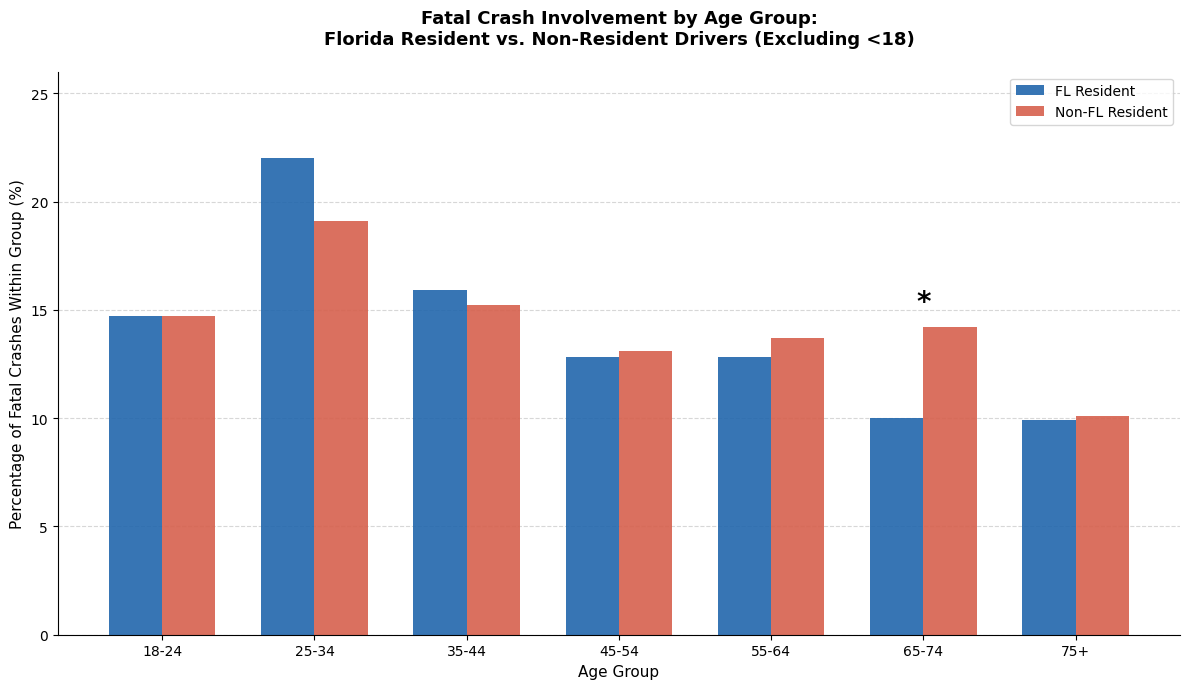

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#load the data generated by the analysis script
df = pd.read_csv("age_alcohol_drugs_full_analysis.csv")

#filter specifically for 'Age (crashes)' and exclude the 0-17 group
age_df = df[(df['Analysis'] == 'Age (crashes)') & (df['Age Group'] != '0-17')].copy()

#define the age groups in the correct order
AGE_GROUPS = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
age_df = age_df.set_index('Age Group').reindex(AGE_GROUPS).reset_index()

#extract plotting data
res_pcts = age_df['Resident_Pct'].values.astype(float)
nonres_pcts = age_df['NonResident_Pct'].fillna(0).values.astype(float)
significant = age_df['Significant'].values

#setup the Visualization
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(AGE_GROUPS))
BAR_WIDTH = 0.35
RES_COLOR = "#2166ac"
NONRES_COLOR = "#d6604d"

#plot the grouped bars
ax.bar(x - BAR_WIDTH/2, res_pcts, BAR_WIDTH, label='FL Resident', color=RES_COLOR, alpha=0.9)
ax.bar(x + BAR_WIDTH/2, nonres_pcts, BAR_WIDTH, label='Non-FL Resident', color=NONRES_COLOR, alpha=0.9)

#add Significance Markers (*) based on the Chi-Square results
for i, sig_val in enumerate(significant):
    if sig_val == 'Yes *':
        h = max(res_pcts[i], nonres_pcts[i])
        ax.text(x[i], h + 0.5, '*', ha='center', va='bottom', fontsize=20, fontweight='bold')

#styling and formatting
ax.set_title('Fatal Crash Involvement by Age Group:\nFlorida Resident vs. Non-Resident Drivers (Excluding <18)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Percentage of Fatal Crashes Within Group (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(AGE_GROUPS, fontsize=10)
ax.set_ylim(0, max(max(res_pcts), max(nonres_pcts)) + 4) #Adjust for star height
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig("age_crash_distribution_final.png", dpi=300)

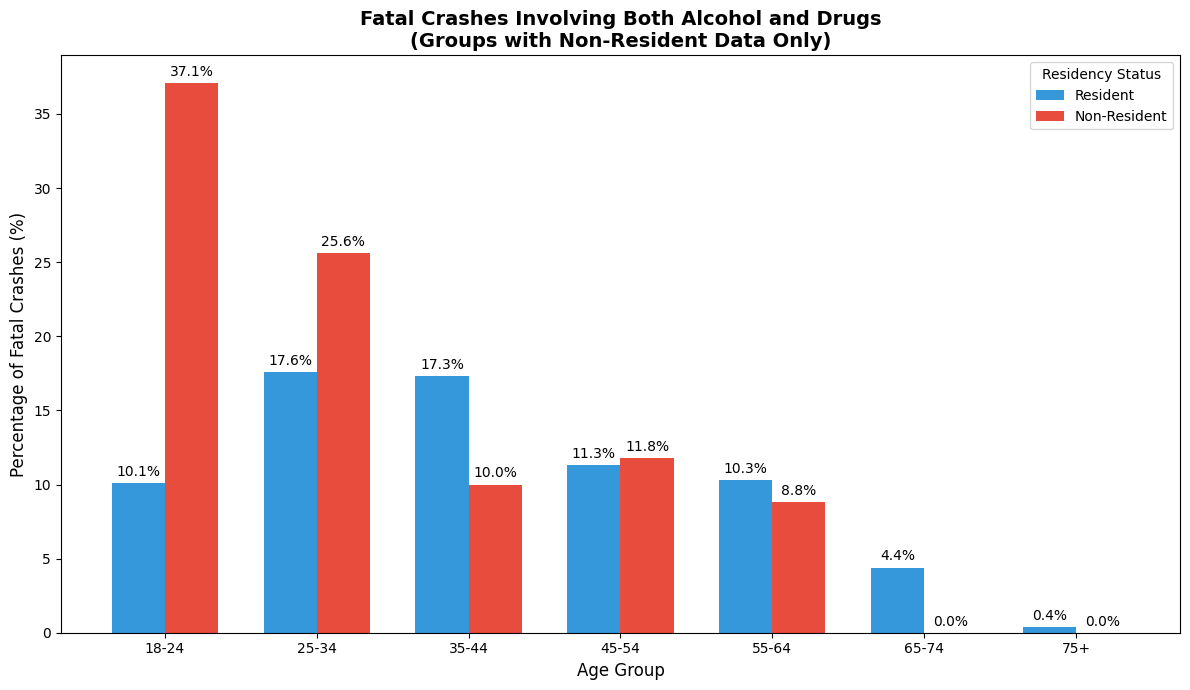

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('age_alcohol_drugs_full_analysis.csv')

#filter for 'Alcohol AND Drugs' AND exclude groups with 0 non-residents
#This removes the 0-17 group and any others with insufficient data
df_filtered = df[(df['Analysis'] == 'Alcohol AND Drugs') & (df['NonResident_N'] > 0)].copy()

#prepare data for plotting
age_groups = df_filtered['Age Group'].tolist()
resident_vals = df_filtered['Resident_Pct'].tolist()
non_resident_vals = df_filtered['NonResident_Pct'].tolist()

x = np.arange(len(age_groups))
width = 0.35
#create the plot
fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, resident_vals, width, label='Resident', color='#3498db')
rects2 = ax.bar(x + width/2, non_resident_vals, width, label='Non-Resident', color='#e74c3c')

#formatting
ax.set_ylabel('Percentage of Fatal Crashes (%)', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_title('Fatal Crashes Involving Both Alcohol and Drugs\n(Groups with Non-Resident Data Only)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_groups)
ax.legend(title="Residency Status")
#function to add percentage labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)
autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.savefig('alc_drugs.png')